# Работа с данными бизнеса в ClickHouse

## Задание 1

In [3]:
SELECT 
usage_geo_id_name as geolocation,
ROUND(sum(main_content_duration_hours )) as all_duration,
ROUND(sumIf(main_content_duration_hours , usage_platform_ru = 'Букмейт iOS')) as duration_ios,
ROUND(sumIf(main_content_duration_hours , usage_platform_ru = 'Букмейт Android')) as duration_android
FROM source_db.audition a
Inner join source_db.content c using(main_content_id)
Where usage_geo_id_name NOT LIKE '%федеральный%' and usage_platform_ru IN ('Букмейт iOS','Букмейт Android')
Group by geolocation
order by all_duration desc
Limit 20

SyntaxError: invalid syntax (3610108104.py, line 2)

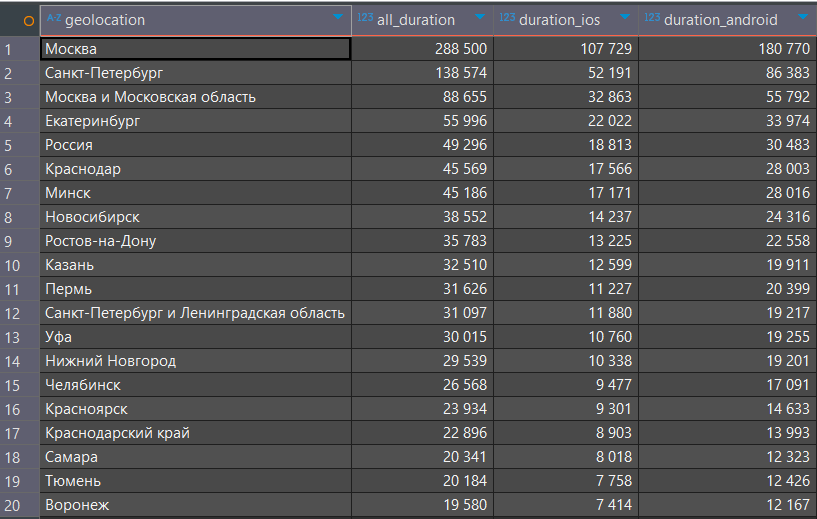

1. Ключевые наблюдения по `топ-20` городов/регионов:
 - Москва: `288 500 часов`
 - СПб: `138 574 часа`
    На два города приходится более 50% от всей активности в топ-20.
 - Также к Москве добавляется Московская область, итого 1 и 3 места в топе дают `~377 тыс. часов.`
   Это подтверждает, что Центральный регион — ядро аудитории.
2. Распределение по платформам
- В Москве: `iOS ≈ 107 тыс.`, `Android ≈ 180 тыс.`. `Android` лидирует, составляя `~63%` от общего.
- В Питере аналогично -  Android составляет `~62%` от общего: `iOS ≈ 52 тыс.`, `Android ≈ 86 тыс.`.
    На мобильных устройствах пользователи явно чаще используют `Android`-устройства (возможно, из-за ценовой доступности или демографии).
3. Региональная активность
    В топ-10 входят крупные города: 
    -Екатеринбург
    -Новосибирск
    -Казань
    -Ростов-на-Дону 
    -Пермь
    -Уфа
    -Челябинск 
    Все города имеют свыше `30 тыс. часов`.
**`Вывод:`**

`Яндекс Книга` наиболее популярна в крупных городах Центральной России (`Москва`, `СПб`), причём основной трафик приходит с `Android-устройств`. Региональные центры (`Екатеринбург`, `Новосибирск`, `Казань` и др.) демонстрируют устойчивую активность - это потенциал для локальных маркетинговых кампаний. Доля `Android` превышает 60% даже в мегаполисах, что указывает на важность оптимизации под эту платформу.

## Задание 2

In [2]:
WITH filtered_events AS (
    SELECT 
        c.main_content_name,
        c.main_author_name,
        c.main_content_type,
        c.main_content_duration_hours,
        avgIf(c.main_content_duration_hours, c.main_content_type = 'Book') OVER () AS avg_book,
        avgIf(c.main_content_duration_hours, c.main_content_type = 'Audiobook') OVER () AS avg_audiobook
    FROM source_db.audition a
    JOIN source_db.content c ON a.main_content_id = c.main_content_id
    WHERE 
        a.usage_geo_id_name NOT LIKE '%федеральный%'
        AND a.usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
        AND c.main_content_type IN ('Book', 'Audiobook')
),
books_in_both AS (
    SELECT main_content_name, main_author_name
    FROM filtered_events
    GROUP BY main_content_name, main_author_name
    HAVING uniq(main_content_type) = 2
)
SELECT 
    f.main_content_name AS title,
    f.main_author_name AS author,
    ROUND(SUM(f.main_content_duration_hours), 2) AS all_duration,
    ROUND(any(f.avg_book), 2) AS duration_book,
    ROUND(any(f.avg_audiobook), 2) AS duration_audiobook
FROM filtered_events f
JOIN books_in_both b USING (main_content_name, main_author_name)
GROUP BY f.main_content_name, f.main_author_name
ORDER BY all_duration DESC
LIMIT 5

SyntaxError: invalid syntax (816408431.py, line 1)

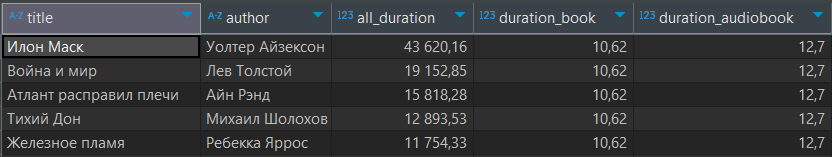

**`Вывод:`**

- Все 5 книг - массовые бестселлеры, это ожидаемо.
- Среднее время чтения текстовой версии составлят `10,62 часа`
- Среднее время прослушивания аудиоверсии немного больше, `12,7 часов`

Аудиокниги используются дольше (на `~20%`), возможно, из-за многозадачности (слушают за рулём, на прогулке и т.д.).

## Задание 3

In [ ]:
WITH 
book_stats AS (
    SELECT 
        c.main_author_name,
        SUM(c.main_content_duration_hours) AS sum_book,
        uniqExact(c.main_content_id) AS uniq_book
    FROM source_db.audition a
    JOIN source_db.content c ON a.main_content_id = c.main_content_id
    WHERE 
        a.usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android', 'Букмейт Web')
        AND c.main_content_type = 'Book'
    GROUP BY c.main_author_name
),
mobile_audio_stats AS (
    SELECT 
        c.main_author_name,
        AVG(c.main_content_duration_hours) AS avg_audiobook
    FROM source_db.audition a
    JOIN source_db.content c ON a.main_content_id = c.main_content_id
    WHERE 
        a.usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
        AND c.main_content_type = 'Audiobook'
    GROUP BY c.main_author_name
)

SELECT 
    b.main_author_name AS author,
    b.sum_book,
    b.uniq_book,
    ROUND(m.avg_audiobook, 2) AS avg_audiobook
FROM book_stats b
JOIN mobile_audio_stats m 
    ON b.main_author_name = m.main_author_name
ORDER BY b.sum_book DESC
LIMIT 10

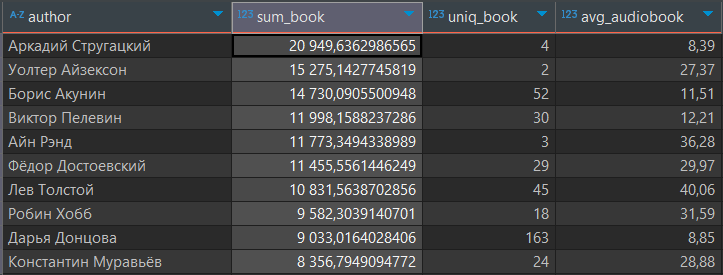

**`Вывод:`**

1. Лидеры по глубине вовлечённости

- `Аркадий Стругацкий` возглавляет рейтинг с `20 949` часами чтения, несмотря на то, что у него представлено всего `4` книги в каталоге.
    Это говорит о высокой лояльности аудитории: пользователи перечитывают или долго работают с текстом.
    В топ-5 также вошли `Уолтер Айзексон`, `Борис Акунин`, `Виктор Пелевин` и `Айн Рэнд` - все они представляют «тяжёлую» литературу (биографии, классика, философия), требующую концентрации.
    
2. Соотношение качества и количества
- Дарья Донцова лидер по количеству книг (`163` книги), но занимает лишь `9-е` место по сумме чтения.
    Её аудитория читает много, но быстро, типично для лёгкой детективной прозы.
- В то же время `Лев Толстой` (`45` книг) и `Фёдор Достоевский` (`29` книг) демонстрируют высокую суммарную вовлечённость, несмотря на меньшее количество изданий в цифровом формате.

3. Аудиокниги: длина контента vs поведение
- Самые длинные аудиосессии - у классиков:
    - Лев Толстой: `40,06 ч` в среднем,
    - Фёдор Достоевский: `29,97 ч`,
    - Айн Рэнд: `36,28 ч`.
    Это соответствует реальной длительности аудиокниг («Война и мир», «Атлант расправил плечи» - десятки часов).
- У массовых авторов (`Стругацкий`, `Донцова`) среднее прослушивание ниже `9` часов - их аудиокниги короче, либо пользователи слушают фрагментарно.

4. Мобильная аудиоаудитория
- Все авторы в топе имеют значимую активность на мобильных платформах, что подтверждает:
  - Аудиокниги - преимущественно мобильный формат.
- При этом текстовые книги активно читаются и на вебе (особенно длинные произведения), что говорит о разделении сценариев:
    - Web/Desktop - для глубокого чтения,
    - Мобильные - для прослушивания в дороге, на прогулке и т.д.

## Задание 4


In [ ]:
With users_stats AS (
    SELECT 
    puid,
    sumIf(c.main_content_duration_hours, c.main_content_type = 'Book') AS total_book,
    sumIf(c.main_content_duration_hours, c.main_content_type = 'Audiobook') AS total_audio,
    sumIf(c.main_content_duration_hours, a.usage_platform_ru = 'Букмейт iOS') AS ios_time,
    sumIf(c.main_content_duration_hours, a.usage_platform_ru = 'Букмейт Android') AS android_time
    FROM source_db.audition a
    JOIN source_db.content c ON a.main_content_id = c.main_content_id
    WHERE 
        a.usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
        AND c.main_content_type IN ('Book', 'Audiobook')
    GROUP BY puid
    HAVING total_book + total_audio > 0)
SELECT 
    multiIf(
        total_audio / (total_book + total_audio) >= 0.7, 'Слушатель',
        total_book / (total_book + total_audio) >= 0.7, 'Читатель',
        'Оба'
    ) AS segment,
    if(ios_time > android_time, 'iOS', 'Android') AS main_platform,
    count(*) AS users_count
FROM users_stats
GROUP BY main_platform, segment
ORDER BY main_platform, users_count DESC


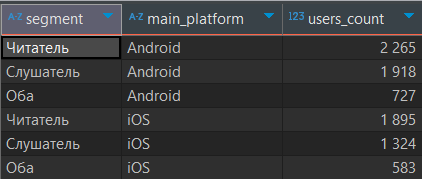

1. Гипотеза 1:
**«Среди Android-пользователей аудиокниги почти так же популярны, как тексты»**
- Читатели (Android): `2 265`
- Слушатели (Android): `1 918`

    Соотношение `1,18` к `1`, разница `~18%`, что почти одинаково. Гипотеза подтверждена.


2. Гипотеза 2:
**«Среди iOS-пользователей читателей вдвое больше, чем слушателей»**
- Читатели (iOS): `1 895`
- Слушатели (iOS): `1 324`

    Соотношение `1,43` к `1`, больше в `1,4` раза.

- Гипотеза частично верна: читателей больше, но не в `2` раза, а на `43%` больше.

3. Оба направления:
- на `Android` доля «Оба» `≈ 17%`
- на `iOS` доля «Оба» `≈ 15%`

    Данные почти одинаковы, пользователи обеих платформ склонны использовать оба формата и не доминируют в одном.

**`Вывод:`**
Гипотеза о сбалансированности форматов на `Android` подтвердилась. 
На `iOS` читателей действительно больше, но не вдвое, а примерно на `40%`. Это говорит о том, что `iOS-аудитория` предпочитает чтение, но аудио остаётся значимым каналом.

## Задание 5

In [ ]:
Select
c.main_content_type,
if(toDayOfWeek(msk_business_dt_str) IN (6, 7), 'Выходные','Будни') as day_category,
Round(avg(hours_sessions_long),2) AS avg_session_hours
FROM source_db.audition a
JOIN source_db.content c ON a.main_content_id = c.main_content_id
WHERE 
a.usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android', 'Букмейт Web')
AND c.main_content_type IN ('Book', 'Audiobook')
GROUP BY c.main_content_type, day_category
ORDER BY 
    c.main_content_type,
    day_category = 'Будни' DESC

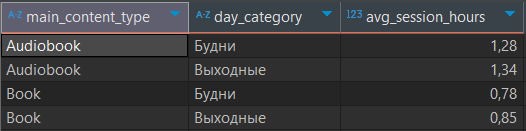

**`Вывод:`**

1. Средняя сессия аудиокниги в выходные: `1,34 ч`,
   В будни: `1,28 ч`

    Пользователи слушают аудиокниги в выходные дольше на `4,7%`.
2. У чтения аналогичная ситуация:
- Средняя сессия чтения в будни `0,78`, в выходные - `0,85 ч`, увеличение на `9%` 

Оба формата используются активнее в выходные, но разница небольшая.

Связь между длительностью и днем недели прослеживается, аудиокниги не падают в выходные - их средняя сессия даже немного увеличивается.

Это может означать, что пользователи в выходные больше времени проводят дома и предпочитают пассивное потребление (слушание), но при этом и чтение тоже растёт.
Нет явного `«провала»` аудио в выходные - `гипотеза спада активности в выходные дни опровергнута`.

## Задание 6

Добавьте запрос для решения задания как текст или код.

In [ ]:
WITH latest_versions AS (
    SELECT 
        usage_platform_ru,
        argMax(app_version, msk_business_dt_str) AS latest_version
    FROM source_db.audition
    WHERE usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
      AND app_version IS NOT NULL
    GROUP BY usage_platform_ru
),

user_latest AS (
    SELECT 
        puid,
        usage_platform_ru,
        argMax(app_version, msk_business_dt_str) AS user_version
    FROM source_db.audition
    WHERE usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
      AND app_version IS NOT NULL
    GROUP BY puid, usage_platform_ru
)
SELECT 
    u.usage_platform_ru AS platform,
    ROUND(countIf(u.user_version = l.latest_version) * 100.0 / COUNT(*),2) AS percent_on_latest
FROM user_latest u
JOIN latest_versions l ON u.usage_platform_ru = l.usage_platform_ru
GROUP BY u.usage_platform_ru
ORDER BY platform

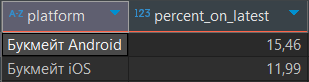

Гипотеза:
**«Больший процент пользователей iOS используют последнюю версию приложения и в целом чаще его обновляют»**

- на `Android` - `15,46%` пользователей на последней версии
- на `iOS` - `11,99%` пользователей

То есть доля пользователей на `Android` выше на `~3,5` п.п.

**`Вывод:`**

Гипотеза опровергнута.

Пользователи `Android` активнее обновляются (например, из-за автоматических обновлений в `Google Play`) или `iOS-пользователи` дольше остаются на старых версиях (возможно, не обновляют `iOS/приложение` из-за боязни потери функционала или совместимости).

## Задание 7

In [ ]:
With users_stats AS (
SELECT 
    puid,
    usage_platform_ru,
    app_version,
    msk_business_dt_str,
    lagInFrame(app_version, 1) OVER (PARTITION BY puid ORDER BY msk_business_dt_str) AS prev_version
FROM source_db.audition
WHERE 
    usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
    AND app_version IS NOT NULL
ORDER BY 
    puid,
    usage_platform_ru,
    msk_business_dt_str), 

user_updates AS (
    SELECT 
        puid,
        usage_platform_ru,
        countIf(app_version != prev_version) AS updates_count 
    FROM users_stats
    GROUP BY puid, usage_platform_ru
)
SELECT 
    usage_platform_ru,
    ROUND(avg(updates_count), 2) AS update_rate
FROM user_updates
GROUP BY usage_platform_ru
ORDER BY usage_platform_ru

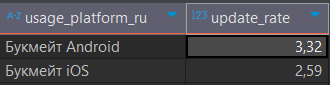

Гипотеза: **«Пользователи iOS чаще обновляют приложение»**

- Среднее количество обновлений на пользователя:
    - `Android`: `3,32` раза
    - `iOS`: `2,59` раза
  
  Разница в `0,73`раза обновления на пользователя приходится в пользу `Android`. Пользователи `Android` обновляют приложение чаще, а не реже.
  
- Возможные причины:
    - Автообновления в `Google Play` (часто включены по умолчанию),
    - Меньше боязни `«сломать»` устройство при обновлении (в отличие от `iOS`, где пользователи осторожнее),
    - Возможно, данные охватывают период, когда вышло несколько крупных обновлений для `Android-версии`.

**`Вывод:`**

Гипотеза опровергнута.
Средняя частота обновлений выше на `Android` (`3.32` vs `2.59`). 
Гипотеза о том, что `iOS-пользователи` обновляются чаще, не подтверждена.

## Задание 8

In [ ]:
SELECT 
countIf(has(published_topic_title_list, 'Магия')) AS magical_books
FROM source_db.content c;

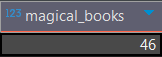

Всего найдено `46` книг с тегом `"Магия"`.

## Задание 9

In [ ]:
SELECT 
    countIf(main_content_name ILIKE '%магия%') AS books_count
FROM source_db.content
WHERE 
    NOT has(published_topic_title_list, 'Магия')
    AND NOT has(published_topic_title_list, 'Художественная литература')

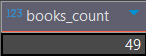

Найдено `49` книг с наименованием `магия`, среди которых нет тегов `Магия` и `Художественная литература`.

## Задание 10

In [ ]:
SELECT
    ROUND(avgIf(length(published_topic_title_list), has(published_topic_title_list, 'Магия')), 2) AS avg_tags_magical_books,
    ROUND(avg(length(published_topic_title_list)), 2) AS avg_tags_all_books
FROM source_db.content

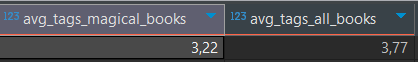

**`Вывод:`**

- Среднее количество тегов у книг с тегом `«Магия»` `3,22`, что указывает на пределы нормы (`важно, чтобы у каждой книги было не больше 3–4 категорий`).
- Среднее по всем книгам `3,77`, что также не превышает `4`, но ближе к указанной границе.

Рекомендованное количество категорий (`3-4`) соблюдается в среднем как для магических книг, так и для всего каталога.
Ни одна из групп не выходит за лимит - переразметка не требуется на уровне средних значений.

## Задание 11

In [ ]:
WITH cv_by_country_platform AS (
    SELECT 
        usage_country_name ,
        usage_platform_ru,
        avg(hours_sessions_long) AS mean_duration,
        stddevPop(hours_sessions_long) AS stddev_duration,
        stddevPop(hours_sessions_long) / avg(hours_sessions_long) AS cv
    FROM source_db.audition
    WHERE 
        usage_platform_ru IN ('Букмейт iOS', 'Букмейт Android')
        AND hours_sessions_long > 0
        AND usage_country_name  IS NOT NULL
    GROUP BY usage_country_name, usage_platform_ru
    HAVING count() >= 10
)

SELECT 
    usage_country_name,
    usage_platform_ru,
    ROUND(cv, 4) AS coefficient_of_variation
FROM cv_by_country_platform
ORDER BY cv DESC
LIMIT 1

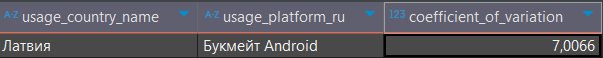

**`Вывод:`**
- `V ≈ 7` означает, что стандартное отклонение в `7 раз` больше среднего, такое распределение крайне нестабильно.
- Это может означать, что:
    - В Латвии на `Android` запись `hours_sessions_long` работает некорректно, часть сессий - нормальные, часть - большие значения или наоборот, фиксируются нули/малые числа из-за бага.
- Аномалия обнаружена в `Латвии` на платформе `«Букмейт Android»`.

Необходимо проверить `логи` и `ETL-процессы` для этой платформы в этой стране, высока вероятность бага в сборе `hours_sessions_long`.